# DeepEval Hallucination Evaluation

The purpose of this notebook is to run test cases of hallucination evaluations on datasets.

## Setup

In [39]:
import os
import json
import pandas as pd
import numpy as np
import random
import time
import sys
import io
import copy
import anthropic

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from dotenv import load_dotenv
from concurrent.futures import ProcessPoolExecutor, as_completed

from deepeval import evaluate
from deepeval.metrics import HallucinationMetric
from deepeval.test_case import LLMTestCase
from deepeval.models.base_model import DeepEvalBaseLLM

In [2]:
os.cpu_count()

40

## LLM Link

In [3]:
load_dotenv()
anthropic_key = os.getenv("ANTHROPIC_KEY")

In [4]:
# define a custom claude model for deepeval
class Claude(DeepEvalBaseLLM):
    """Class to implement Claude model for DeepEval"""
    def __init__(self, model, api_key):
        self.model = model
        self.api_key = api_key
        self.client = anthropic.Anthropic(api_key=self.api_key)

    def load_model(self):
        return self.model

    def generate(self, prompt, max_tokens=8192):
        response = self.client.messages.create(
            model=self.model,
            max_tokens=max_tokens,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.content[0].text

    async def a_generate(self, prompt, max_tokens=8192):
        response = self.client.messages.create(
            model=self.model,
            max_tokens=max_tokens,
            messages=[{"role": "user", "content": prompt}]
        )
        return response.content[0].text

    def get_model_name(self):
        return "Claude Model"

In [5]:
# set up the claude model

claude_model = "claude-3-5-sonnet-20240620"
claude_instance = Claude(model=claude_model, api_key=anthropic_key)

## Data

In [6]:
# load json dataset
file_path = "../../data/Hallucination/qa_data.json"
with open(file_path, "r") as file:
    data = [json.loads(line) for line in file]

In [7]:
data[:3]

[{'knowledge': "Arthur's Magazine (1844–1846) was an American literary periodical published in Philadelphia in the 19th century.First for Women is a woman's magazine published by Bauer Media Group in the USA.",
  'question': "Which magazine was started first Arthur's Magazine or First for Women?",
  'right_answer': "Arthur's Magazine",
  'hallucinated_answer': 'First for Women was started first.'},
 {'knowledge': 'The Oberoi family is an Indian family that is famous for its involvement in hotels, namely through The Oberoi Group.The Oberoi Group is a hotel company with its head office in Delhi.',
  'question': 'The Oberoi family is part of a hotel company that has a head office in what city?',
  'right_answer': 'Delhi',
  'hallucinated_answer': "The Oberoi family's hotel company is based in Mumbai."},
 {'knowledge': 'Allison Beth "Allie" Goertz (born March 2, 1991) is an American musician. Goertz is known for her satirical songs based on various pop culture topics. Her videos are posted

In [24]:
# data preparation

random.seed(42)

records = []
hallucination_flags = []
for entry in data[0:1000]:
    is_hallucinated = random.choice([True, False])
    actual_output = entry["hallucinated_answer"] if is_hallucinated else entry["right_answer"]    
    records.append({
        "input": entry["question"],
        "actual_output": actual_output,
        "context": entry["knowledge"]
    })
    hallucination_flags.append(1 if is_hallucinated else 0)
    
# convert to dataframe
df = pd.DataFrame(records)
hallucination_df = pd.DataFrame({"hallucinated": hallucination_flags})

In [9]:
df.head()

,input,actual_output,context
0,Which magazine was started first Arthur's Maga...,First for Women was started first.,Arthur's Magazine (1844–1846) was an American ...
1,The Oberoi family is part of a hotel company t...,The Oberoi family's hotel company is based in ...,The Oberoi family is an Indian family that is ...
2,Musician and satirist Allie Goertz wrote a son...,President Richard Nixon,"Allison Beth ""Allie"" Goertz (born March 2, 199..."
3,What nationality was James Henry Miller's wife?,James Henry Miller's wife was British.,"Margaret ""Peggy"" Seeger (born June 17, 1935) i..."
4,Cadmium Chloride is slightly soluble in this c...,water with a hint of alcohol,It is a hygroscopic solid that is highly solu...


In [10]:
hallucination_df.head()

,hallucinated
0,1
1,1
2,0
3,1
4,1


In [11]:
hallucination_df['hallucinated'].value_counts()

0    514
1    486
Name: hallucinated, dtype: int64

## DeepEval Evaluation

In [12]:
# creating test cases for evaluation

test_cases = [
    LLMTestCase(
        input=row["input"],
        actual_output=row["actual_output"],
        context=[row["context"]]
    ) for _, row in df.iterrows()
]

In [ ]:
# suppressing excessive output, need to supress more, output still too long
original_stdout = sys.stdout
sys.stdout = io.StringIO()

# start timer
start_time = time.time()

# function to evaluate a single case with error handling
def evaluate_case_safe(test_case):
    try:
        hallucination_metric = HallucinationMetric(model=claude_instance, threshold=0.5, async_mode=False)
        result = evaluate(test_cases=[test_case], metrics=[hallucination_metric])
        return result.test_results
    except Exception as e:
        return None  # skip test case on error

# get available cpu cores and set max workers
cpu_cores = os.cpu_count()
max_workers = min(cpu_cores, 10)  # ensure we don't exceed available cores

# parallel evaluation with tqdm and error handling
test_results = []
with ProcessPoolExecutor(max_workers=max_workers) as executor:
    futures = {executor.submit(evaluate_case_safe, test_case): test_case for test_case in test_cases}
    
    for future in tqdm(futures, total=len(test_cases), desc="Evaluating Test Cases"):
        result = future.result()
        if result is not None:  # only add valid results
            test_results.extend(result)

# restore original stdout
sys.stdout = original_stdout

# end timer
end_time = time.time()

## Results

In [16]:
test_results[0]

TestResult(name='test_case_0', success=False, metrics_data=[MetricData(name='Hallucination', threshold=0.5, success=False, score=1.0, reason="The score is 1.00 because the actual output makes a completely unsupported claim about First for Women being started first, which directly contradicts the available information in the context. The context does not provide any basis for this assertion, and the dates given for Arthur's Magazine suggest it likely predates First for Women.", strict_mode=False, evaluation_model='Claude Model', error=None, evaluation_cost=None, verbose_logs='Verdicts:\n[\n    {\n        "verdict": "no",\n        "reason": "The actual output contradicts the context. The context provides information about two different magazines: Arthur\'s Magazine (1844-1846) and First for Women, but does not specify which was started first. The actual output makes a claim about First for Women being started first, which is not supported by the given context. Based on the dates provided

In [25]:
# get only not none results

valid_results = [result for result in test_results if result is not None]
len(valid_results)

993

In [26]:
# remove none rows from corresponding ground truths

valid_hallucination_flags = [
    hallucination_flags[i] for i, result in enumerate(test_results) if result is not None
]

predicted_hallucinations = [
    1 if result.metrics_data[0].score > 0.5 else 0 for result in valid_results
]

In [27]:
# compute evaluation metrics only for valid results
true_positives = sum(p == 1 and h == 1 for p, h in zip(predicted_hallucinations, valid_hallucination_flags))
false_positives = sum(p == 1 and h == 0 for p, h in zip(predicted_hallucinations, valid_hallucination_flags))
true_negatives = sum(p == 0 and h == 0 for p, h in zip(predicted_hallucinations, valid_hallucination_flags))
false_negatives = sum(p == 0 and h == 1 for p, h in zip(predicted_hallucinations, valid_hallucination_flags))

# compute metrics
precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
accuracy = (true_positives + true_negatives) / len(valid_results) if len(valid_results) > 0 else 0

# print results
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Time taken: {end_time - start_time:.2f} seconds")

Precision: 0.5471
Recall: 0.3727
Accuracy: 0.5448
Time taken: 491.35 seconds


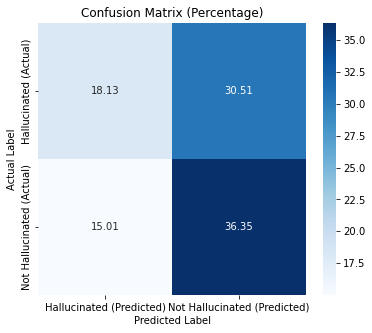

In [41]:
# confusion matrix to understand poor results

total = true_positives + false_positives + true_negatives + false_negatives

# convert to percentage
conf_matrix = np.array([
    [true_positives / total * 100, false_negatives / total * 100],  # Row for actual hallucinations (h=1)
    [false_positives / total * 100, true_negatives / total * 100]   # Row for actual non-hallucinations (h=0)
])

# labels
labels = ["Hallucinated (Predicted)", "Not Hallucinated (Predicted)"]
actual_labels = ["Hallucinated (Actual)", "Not Hallucinated (Actual)"]

# plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt=".2f", cmap="Blues", xticklabels=labels, yticklabels=actual_labels)

# titles and labels
plt.title("Confusion Matrix (Percentage)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

# show plot
plt.show()

## Inspection 

Inspect a few miss-classified examples to understand reasoning

In [28]:
valid_hallucination_flags[0:10]

[1, 1, 0, 1, 1, 1, 1, 1, 0, 1]

In [29]:
predicted_hallucinations[0:10]

[1, 1, 0, 1, 0, 1, 0, 0, 0, 1]

In [30]:
test_results[4]

TestResult(name='test_case_0', success=True, metrics_data=[MetricData(name='Hallucination', threshold=0.5, success=True, score=0.0, reason="The score is 0.00 because the actual output perfectly aligns with the given context, accurately describing ethanol's solubility in water and alcohol without any contradictions or unsupported claims.", strict_mode=False, evaluation_model='Claude Model', error=None, evaluation_cost=None, verbose_logs='Verdicts:\n[\n    {\n        "verdict": "yes",\n        "reason": "The actual output \'water with a hint of alcohol\' is consistent with the context, which states that ethanol is \'highly soluble in water and slightly soluble in alcohol\'. The description of \'water with a hint of alcohol\' aligns with this solubility characteristic."\n    }\n]')], conversational=False, multimodal=False, input='Cadmium Chloride is slightly soluble in this chemical, it is also called what?', actual_output='water with a hint of alcohol', expected_output=None, context=[' I

In [32]:
data[4]

{'knowledge': ' It is a hygroscopic solid that is highly soluble in water and slightly soluble in alcohol.Ethanol, also called alcohol, ethyl alcohol, and drinking alcohol, is a compound and simple alcohol with the chemical formula C2H5OH .',
 'question': 'Cadmium Chloride is slightly soluble in this chemical, it is also called what?',
 'right_answer': 'alcohol',
 'hallucinated_answer': 'water with a hint of alcohol'}

In [33]:
test_results[6]

TestResult(name='test_case_0', success=True, metrics_data=[MetricData(name='Hallucination', threshold=0.5, success=True, score=0.0, reason='The score is 0.00 because the actual output fully aligns with the provided context, accurately stating that the Indogrammodes genus has only one species and is found in India, with no contradictions identified.', strict_mode=False, evaluation_model='Claude Model', error=None, evaluation_cost=None, verbose_logs='Verdicts:\n[\n    {\n        "verdict": "yes",\n        "reason": "The actual output agrees with the provided context. It correctly states that the Indogrammodes genus of moths has only one species and is found in India, which aligns with the information given in the context."\n    }\n]')], conversational=False, multimodal=False, input="Which genus of moth in the world's seventh-largest country contains only one species?", actual_output='The Indogrammodes genus of moths found in India has only one species.', expected_output=None, context=['I

In [34]:
data[6]

{'knowledge': 'Indogrammodes is a genus of moths of the Crambidae family. It contains only one species, Indogrammodes pectinicornalis, which is found in India.India, officially the Republic of India ("Bhārat Gaṇarājya"), is a country in South Asia. It is the seventh-largest country by area, the second-most populous country (with over 1.2 billion people), and the most populous democracy in the world.',
 'question': "Which genus of moth in the world's seventh-largest country contains only one species?",
 'right_answer': 'Crambidae',
 'hallucinated_answer': 'The Indogrammodes genus of moths found in India has only one species.'}

In [35]:
test_results[7]

TestResult(name='test_case_0', success=True, metrics_data=[MetricData(name='Hallucination', threshold=0.5, success=True, score=0.0, reason='The score is 0.00 because the actual output fully aligns with the context, accurately describing Badr Hari as notorious and reflecting his controversial reputation in kickboxing without any contradictions.', strict_mode=False, evaluation_model='Claude Model', error=None, evaluation_cost=None, verbose_logs='Verdicts:\n[\n    {\n        "verdict": "yes",\n        "reason": "The actual output agrees with the context. The context describes Badr Hari as a prominent figure in kickboxing who has been involved in controversies and crimes of violence, which aligns with the description of him as \'notorious\' in the actual output."\n    }\n]')], conversational=False, multimodal=False, input='Who was once considered the best kick boxer in the world, however he has been involved in a number of controversies relating to his "unsportsmanlike conducts" in the spo

In [36]:
data[7]

{'knowledge': ' Fighters from around world on the roster include Badr Hari, Peter Aerts, Peter Graham, Dewey Cooper, Zabit Samedov. It was considered as one of the biggest kickboxing and MMA promotion in Middle East.Badr Hari (Arabic: بدر هاري\u200e \u200e ; born 8 December 1984) is a Moroccan-Dutch super heavyweight kickboxer from Amsterdam, fighting out of Mike\'s Gym in Oostzaan. Hari has been a prominent figure in the world of kickboxing and was once considered the best kickboxer in the world, however he has been involved in a number of controversies relating to his "unsportsmanlike conducts" in the sport and crimes of violence outside of the ring.',
 'question': 'Who was once considered the best kick boxer in the world, however he has been involved in a number of controversies relating to his "unsportsmanlike conducts" in the sport and crimes of violence outside of the ring.',
 'right_answer': 'Badr Hari',
 'hallucinated_answer': 'Badr Hari is a notorious kickboxer.'}